In [10]:
from sklearn.datasets import load_diabetes

dataset = load_diabetes(return_X_y=False, as_frame=True, scaled=True)
dataset.feature_names

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

array([[<Axes: title={'center': 'age'}>, <Axes: title={'center': 'sex'}>,
        <Axes: title={'center': 'bmi'}>],
       [<Axes: title={'center': 'bp'}>, <Axes: title={'center': 's1'}>,
        <Axes: title={'center': 's2'}>],
       [<Axes: title={'center': 's3'}>, <Axes: title={'center': 's4'}>,
        <Axes: title={'center': 's5'}>],
       [<Axes: title={'center': 's6'}>, <Axes: >, <Axes: >]], dtype=object)

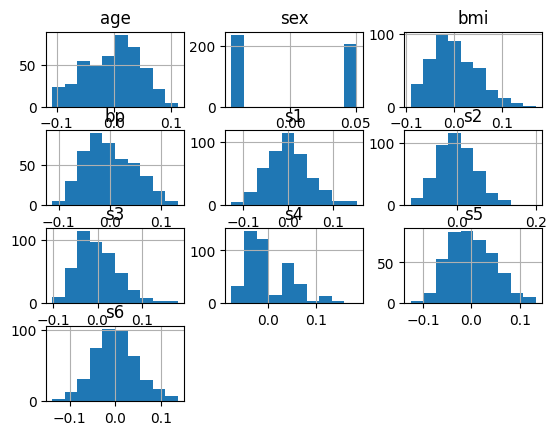

In [3]:
df = dataset.data
target = dataset.target

df.hist(bins=10)

<Axes: >

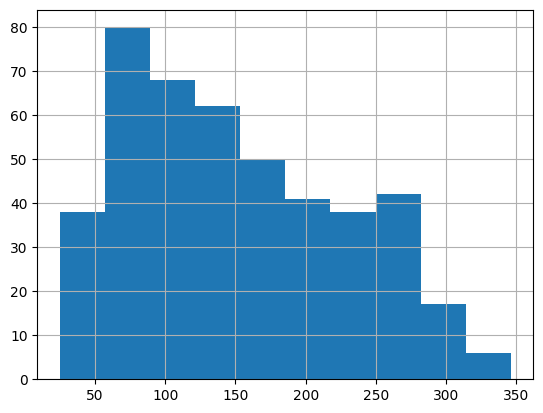

In [11]:
target.hist(bins=10)

In [22]:
df.columns

Index(['age', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6',
       'sex_0.05068011873981862_True'],
      dtype='str')

In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd

df = pd.get_dummies(df, columns=['sex_0.05068011873981862_True'], drop_first=False)

X_train, X_test, y_train, y_test = train_test_split(df, target, test_size=.2, random_state=8774)

In [25]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge, LassoLars, LassoLarsCV, ElasticNetCV

linear = LinearRegression()
lasso = Lasso()
ridge = Ridge()
lars_a1 = LassoLars(alpha=0.5, eps= 500)
lars_a2 = LassoLars(alpha=1, eps=500)
elast = ElasticNetCV()


In [26]:
linear.fit(X_train, y_train)
lasso.fit(X_train, y_train)
ridge.fit(X_train, y_train)
lars_a1.fit(X_train, y_train)
lars_a2.fit(X_train, y_train)

elast.fit(X_train, y_train)



,"l1_ratio l1_ratio: float or list of float, default=0.5Float between 0 and 1 passed to ElasticNet (scaling betweenl1 and l2 penalties). For ``l1_ratio = 0``the penalty is an L2 penalty. For ``l1_ratio = 1`` it is an L1 penalty.For ``0 < l1_ratio < 1``, the penalty is a combination of L1 and L2This parameter can be a list, in which case the differentvalues are tested by cross-validation and the one giving the bestprediction score is used. Note that a good choice of list ofvalues for l1_ratio is often to put more values close to 1(i.e. Lasso) and less close to 0 (i.e. Ridge), as in ``[.1, .5, .7,.9, .95, .99, 1]``.",0.5
,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path, used for each l1_ratio... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path, used for each l1_ratio.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"verbose verbose: bool or int, default=0Amount of verbosity.",0


In [28]:
from sklearn.metrics import root_mean_squared_error

y_linear = linear.predict(X_test)
y_lasso = lasso.predict(X_test)
y_lars1 = lars_a1.predict(X_test)
y_lars2 = lars_a2.predict(X_test)
y_elast = elast.predict(X_test)

predictions = [y_linear, y_lasso, y_lars1, y_lars2, y_elast]



In [30]:
for y in predictions:
    print(root_mean_squared_error(y_test, y))

50.97685306188417
64.16212463475588
81.23224366293226
81.23243183372297
56.070590714371
